# Gaussian integrals → Gaussian beams → related rates
### every step written out, with SymPy (`init_printing`) and a torch check

No skipped steps. We prove the Gaussian integral from scratch, use it to find the
power in a laser beam, and then do a *related-rate* — how fast the beam widens —
which turns out to be the divergence angle. The point: one integral underlies
Gaussian beams, the quantum minimum-uncertainty state, and the Dirac delta.
You don't need to already know this; we build it line by line.

In [1]:
import sympy as sp
import numpy as np, matplotlib.pyplot as plt
import torch
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import gaussian_beam as gb
sp.init_printing()
print("ready (sympy", sp.__version__, "| torch", torch.__version__, ")")

ready (sympy 1.14.0 | torch 2.11.0+cu128 )


## 1. The Gaussian integral, proved by the squaring trick

We want $I=\int_{-\infty}^{\infty}e^{-a x^2}\,dx$. You can't antidifferentiate
$e^{-ax^2}$ in elementary terms — so the trick is to compute $I^2$ instead:

$$I^2=\left(\int e^{-ax^2}dx\right)\left(\int e^{-ay^2}dy\right)
   =\iint e^{-a(x^2+y^2)}\,dx\,dy.$$

Now switch to polar coordinates: $x^2+y^2=r^2$ and $dx\,dy=r\,dr\,d\theta$. The
$r$ that appears is exactly what makes it integrable.

In [2]:
x, y, a, r, th = sp.symbols("x y a r theta", positive=True)

# step A: the radial integral  ∫_0^∞ e^{-a r^2} r dr
radial = sp.integrate(sp.exp(-a*r**2) * r, (r, 0, sp.oo))
print("step A — radial integral  ∫_0^∞ e^{-a r^2} r dr ="); display(radial)

# step B: the angular integral  ∫_0^{2π} dθ = 2π, so I^2 = 2π * radial
I_squared = sp.integrate(radial, (th, 0, 2*sp.pi))
print("step B — I^2 = ∫_0^{2π} (radial) dθ ="); display(I_squared)

# step C: I = sqrt(I^2)
I_val = sp.sqrt(I_squared)
print("step C — I = sqrt(I^2) ="); display(I_val)

# check: let SymPy do the 1-D integral directly
direct = sp.integrate(sp.exp(-a*x**2), (x, -sp.oo, sp.oo))
print("direct 1-D integral (check) ="); display(direct)
assert sp.simplify(I_val - direct) == 0
print("they match ✓   so  ∫ e^{-a x^2} dx = sqrt(pi/a)")

step A — radial integral  ∫_0^∞ e^{-a r^2} r dr =


step B — I^2 = ∫_0^{2π} (radial) dθ =


step C — I = sqrt(I^2) =


direct 1-D integral (check) =


they match ✓   so  ∫ e^{-a x^2} dx = sqrt(pi/a)


## 2. The second moment → the width (variance)

The same integral with an $x^2$ inside gives the **variance** of a Gaussian. For
the probability density $p(x)=\sqrt{a/\pi}\,e^{-ax^2}$ (normalized to 1), the
spread is $\langle x^2\rangle$:

∫ x^2 e^{-a x^2} dx =


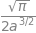

variance <x^2> = (second moment)/(normalization) =


so sigma = 1/sqrt(2a): sqrt(2)/(2*sqrt(a))
This is the SAME sigma that saturates the quantum uncertainty principle.


In [3]:
m0 = sp.integrate(sp.exp(-a*x**2), (x, -sp.oo, sp.oo))             # normalization
m2 = sp.integrate(x**2 * sp.exp(-a*x**2), (x, -sp.oo, sp.oo))      # second moment
print("∫ x^2 e^{-a x^2} dx ="); display(m2)
variance = sp.simplify(m2 / m0)
print("variance <x^2> = (second moment)/(normalization) ="); display(variance)
print("so sigma = 1/sqrt(2a):", sp.sqrt(variance))
print("This is the SAME sigma that saturates the quantum uncertainty principle.")

## 3. Power in a Gaussian beam (the integral, applied)

A laser beam's intensity falls off as $I(r)=I_0\,e^{-2r^2/w^2}$ across the beam.
The **total power** is the integral over the cross-section,
$P=\int_0^\infty I(r)\,2\pi r\,dr$ — and it's just the Gaussian integral again:

In [4]:
w, I0 = sp.symbols("w I_0", positive=True)
P = sp.integrate(I0 * sp.exp(-2*r**2/w**2) * 2*sp.pi*r, (r, 0, sp.oo))
print("total power P = ∫_0^∞ I_0 e^{-2 r^2/w^2} (2π r) dr ="); display(P)
print("=> P = (π w^2 / 2) I_0 : a wider beam (bigger w) carries more power at fixed I_0")

total power P = ∫_0^∞ I_0 e^{-2 r^2/w^2} (2π r) dr =


=> P = (π w^2 / 2) I_0 : a wider beam (bigger w) carries more power at fixed I_0


## 4. Related rate — how fast does the beam widen?

The beam width is $w(z)=w_0\sqrt{1+(z/z_R)^2}$. A *related rate* asks for
$dw/dz$: how fast the spot grows as the light travels. We differentiate
explicitly, then take the far-field limit — which is the **divergence angle**.

w(z) =


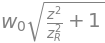

related rate  dw/dz =


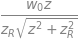

far-field limit  dw/dz (z→∞) =


= w_0/z_R = the beam's divergence (half-)angle θ. The rate of widening
at infinity IS the divergence angle.


In [5]:
z, w0, zR = sp.symbols("z w_0 z_R", positive=True)
w_of_z = w0 * sp.sqrt(1 + (z/zR)**2)
print("w(z) ="); display(w_of_z)
dw_dz = sp.diff(w_of_z, z)
print("related rate  dw/dz ="); display(sp.simplify(dw_dz))
far = sp.limit(dw_dz, z, sp.oo)
print("far-field limit  dw/dz (z→∞) ="); display(far)
print("= w_0/z_R = the beam's divergence (half-)angle θ. The rate of widening")
print("at infinity IS the divergence angle.")

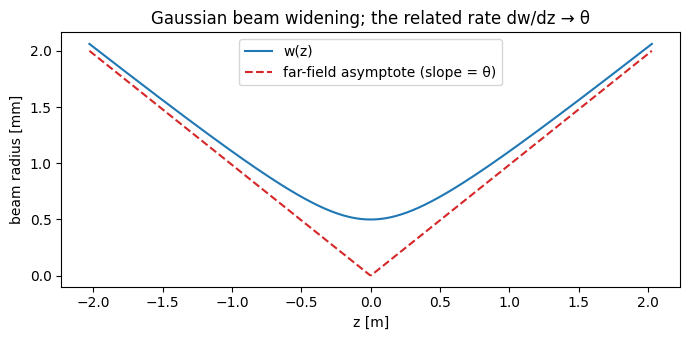

divergence θ = λ/(π w0) = 0.987 mrad


In [6]:
# numbers + picture from gaussian_beam.py (w0=0.5mm, 1550nm)
w0v, lam = 0.5e-3, 1.55e-6; zRv = gb.rayleigh_range(w0v, lam)
zz = np.linspace(-4*zRv, 4*zRv, 400)
plt.figure(figsize=(7,3.5))
plt.plot(zz, gb.beam_width(zz, w0v, lam)*1e3, color="#1f77b4", label="w(z)")
plt.plot(zz, np.abs(zz)*gb.divergence(w0v, lam)*1e3, "--", color="#d62728",
         label="far-field asymptote (slope = θ)")
plt.xlabel("z [m]"); plt.ylabel("beam radius [mm]"); plt.legend()
plt.title("Gaussian beam widening; the related rate dw/dz → θ"); plt.tight_layout(); plt.show()
print(f"divergence θ = λ/(π w0) = {gb.divergence(w0v,lam)*1e3:.3f} mrad")

## 5. Torch numerical check (trust, but verify)
Confirm the symbolic results numerically by integrating on a grid with torch.

In [7]:
a_val = 2.0
xt = torch.linspace(-12, 12, 200000, dtype=torch.float64)
I_num = torch.trapezoid(torch.exp(-a_val*xt**2), xt)
print(f"∫ e^(-2 x^2) dx:  torch = {I_num:.6f},  sqrt(pi/2) = {np.sqrt(np.pi/a_val):.6f}")
var_num = torch.trapezoid(xt**2*torch.exp(-a_val*xt**2), xt) / I_num
print(f"variance:        torch = {var_num:.6f},  1/(2a) = {1/(2*a_val):.6f}")

∫ e^(-2 x^2) dx:  torch = 1.253314,  sqrt(pi/2) = 1.253314


variance:        torch = 0.250000,  1/(2a) = 0.250000


## 6. The same Gaussian becomes the Dirac delta (classical → quantum)

Normalize the Gaussian to area 1 and let it get narrow ($a\to\infty$): it keeps
unit area but shrinks to a spike — that's the **Dirac delta**. So one shape spans
it all: a probability bump, a laser-beam profile, the quantum
minimum-uncertainty state, and (in the limit) the delta that picks out a point.

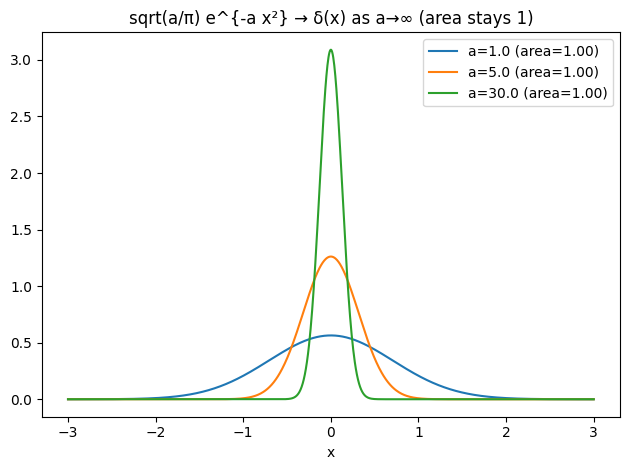

In [8]:
for a_val in (1.0, 5.0, 30.0):
    xx = np.linspace(-3, 3, 1000)
    g = np.sqrt(a_val/np.pi)*np.exp(-a_val*xx**2)
    area = np.trapezoid(g, xx)
    plt.plot(xx, g, label=f"a={a_val} (area={area:.2f})")
plt.legend(); plt.title("sqrt(a/π) e^{-a x²} → δ(x) as a→∞ (area stays 1)")
plt.xlabel("x"); plt.tight_layout(); plt.show()

## What you just proved (the axioms → theorems chain)

1. **Gaussian integral:** $\int e^{-ax^2}dx=\sqrt{\pi/a}$ — by squaring and going polar.
2. **Width:** the variance is $1/(2a)$, so $\sigma=1/\sqrt{2a}$ (the QM uncertainty Gaussian).
3. **Beam power:** $P=\tfrac{\pi w^2}{2}I_0$ — the same integral, over a beam.
4. **Related rate:** $dw/dz\to w_0/z_R=\theta$, the divergence angle.
5. **Limit:** the normalized Gaussian $\to\delta(x)$.

Every step was shown; nothing was assumed. The Gaussian is one idea wearing many
hats — beams, probability, quantum states, and the delta. Civilian education.